# 01_basic_circuits

Purpose:
- Construct simple quantum circuits explicitly
- Understand gates, measurement, and results
- Build intuition before algorithms


Estimated probabilities (from sampling):
{'1': 1.0}


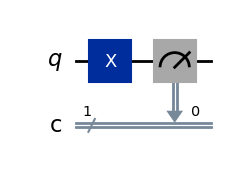

In [5]:
# 01_basic_circuits.ipynb — Cell 1
# Goal: build a 1-qubit circuit, apply an X gate, measure, and run on a simulator.

from qiskit import QuantumCircuit
from qiskit.primitives import Sampler  # simple built-in simulator interface (no Aer needed)
#from IPython.display import display # same as %matplotlib inline
%matplotlib inline

# 1) Create a circuit with 1 qubit and 1 classical bit (to store the measurement result)
qc = QuantumCircuit(1, 1)

# 2) Apply an X gate (bit-flip). This takes |0> -> |1>.
qc.x(0)

# 3) Measure qubit 0 into classical bit 0.
qc.measure(0, 0)

# 4) Inspect the circuit
# print(qc)
# Polished circuit visualization using Matplotlib
#display(qc.draw(output="mpl")) # same as qc.draw(output="mpl") + %matplotlib inline, if display is used
qc.draw(output="mpl") 

# 5) Run on a simulator via the Sampler primitive (shot-based sampling)
sampler = Sampler()
job = sampler.run([qc], shots=1000)
result = job.result()

# 6) Extract and display counts. Expect almost all results to be '1'.
quasi = result.quasi_dists[0]
counts = quasi.binary_probabilities()  # keys like '0'/'1' with probabilities

print("\nEstimated probabilities (from sampling):")
print(counts)

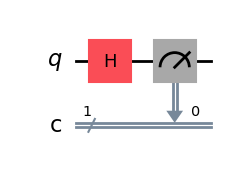

In [10]:
# 01_basic_circuits.ipynb — Cell 2
# Goal: apply a Hadamard gate to create superposition, then measure.

from qiskit import QuantumCircuit
from qiskit.primitives import Sampler
%matplotlib inline

# 1) Create a circuit with 1 qubit and 1 classical bit
qc_h = QuantumCircuit(1, 1)

# 2) Apply a Hadamard gate.
# This takes |0> -> (|0> + |1>) / sqrt(2)
qc_h.h(0)

# 3) Measure the qubit
qc_h.measure(0, 0)

# 4) Draw the circuit (polished visualization)
qc_h.draw(output="mpl"); # to avoid outputing the circuit twice (Jupyter quirk: the last object in a cell is automatically displayed)
# _ = qc_h.draw(output="mpl") # same as above, when drawing is not on the last line

In [3]:
# 5) Execute on a simulator using the Sampler primitive
sampler = Sampler()
job = sampler.run([qc_h], shots=1000)
result = job.result()

# 6) Extract and display measurement probabilities
quasi = result.quasi_dists[0]
counts = quasi.binary_probabilities()

print("Estimated probabilities (from sampling):")
print(counts)

Estimated probabilities (from sampling):
{'0': 0.504, '1': 0.496}


In [4]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)

state = Statevector.from_instruction(qc)
print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
